<a href="https://colab.research.google.com/github/AmanGupta3995377/Celebal-DataScience-Internship/blob/main/Week-6/Week6_Aman_Gupta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 6 Assignment - Image Denoising using Autoencoder

## Objective

To build a Denoising Autoencoder capable of removing noise from MNIST handwritten digit images and reconstructing cleaner versions of the images.



## Problem Statement

Image noise can affect the quality and usability of visual data. The objective of this assignment is to design and train a Denoising Autoencoder that learns to reconstruct clean images from noisy inputs using the MNIST dataset.

The model will be trained using noisy images as input and clean images as target outputs. The denoising performance will be evaluated through visual comparison of original, noisy, and reconstructed images.

## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D
)

## Loading and Preprocessing the MNIST Dataset

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

print("Training Images Shape:", x_train.shape)
print("Testing Images Shape :", x_test.shape)

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

print("\nAfter Preprocessing")
print("Training Shape:", x_train.shape)
print("Testing Shape :", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images Shape: (60000, 28, 28)
Testing Images Shape : (10000, 28, 28)

After Preprocessing
Training Shape: (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)


## Adding Noise to Images

In [3]:
noise_factor = 0.4

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Noise added successfully.")

Noise added successfully.


## Visualize Original and Noisy Images

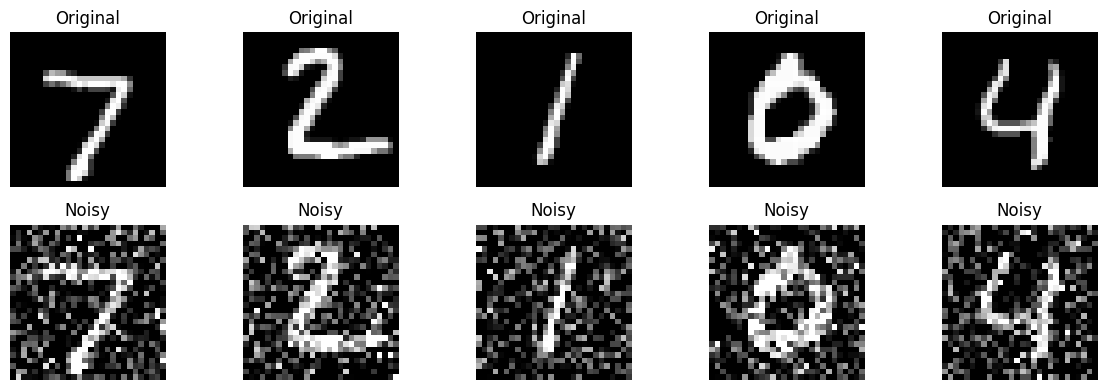

In [4]:
plt.figure(figsize=(12,4))

for i in range(5):

    # Original Images
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy Images
    plt.subplot(2,5,i+6)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Building the Denoising Autoencoder

In [5]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

input_img = Input(shape=(28, 28, 1))

# Encoder

x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder

x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [12]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0838 - val_loss: 0.0837
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0837 - val_loss: 0.0837
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0836 - val_loss: 0.0836
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0835 - val_loss: 0.0834
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0835 - val_loss: 0.0835
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0834 - val_loss: 0.0833
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0833 - val_loss: 0.0832
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0833 - val_loss: 0.0834
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0833 - val_loss: 0.0833
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0832 - val_loss: 0.0835
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0832 - val_loss: 0.0833
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step

In [13]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [23]:
print("Noisy Test Shape :", x_test_noisy.shape)
print("Denoised Output Shape :", decoded_imgs.shape)

Noisy Test Shape : (10000, 28, 28, 1)
Denoised Output Shape : (10000, 28, 28, 1)


## Training Loss Visualization

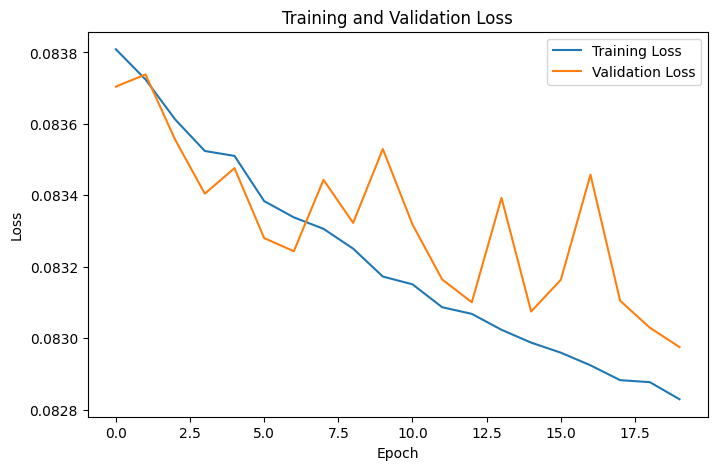

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

## Generate Denoised Images

The trained autoencoder is used to reconstruct cleaner versions of the noisy test images.

In [15]:
decoded_imgs = autoencoder.predict(x_test_noisy)

print("Denoised images generated successfully.")
print("Output Shape:", decoded_imgs.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Denoised images generated successfully.
Output Shape: (10000, 28, 28, 1)


## Visualize Denoised Images

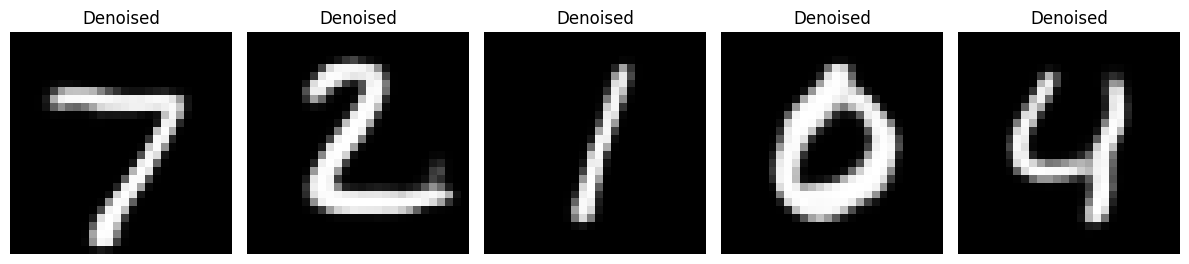

In [16]:
plt.figure(figsize=(12,4))

for i in range(5):

    plt.subplot(1,5,i+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Comparison of Original, Noisy and Denoised Images

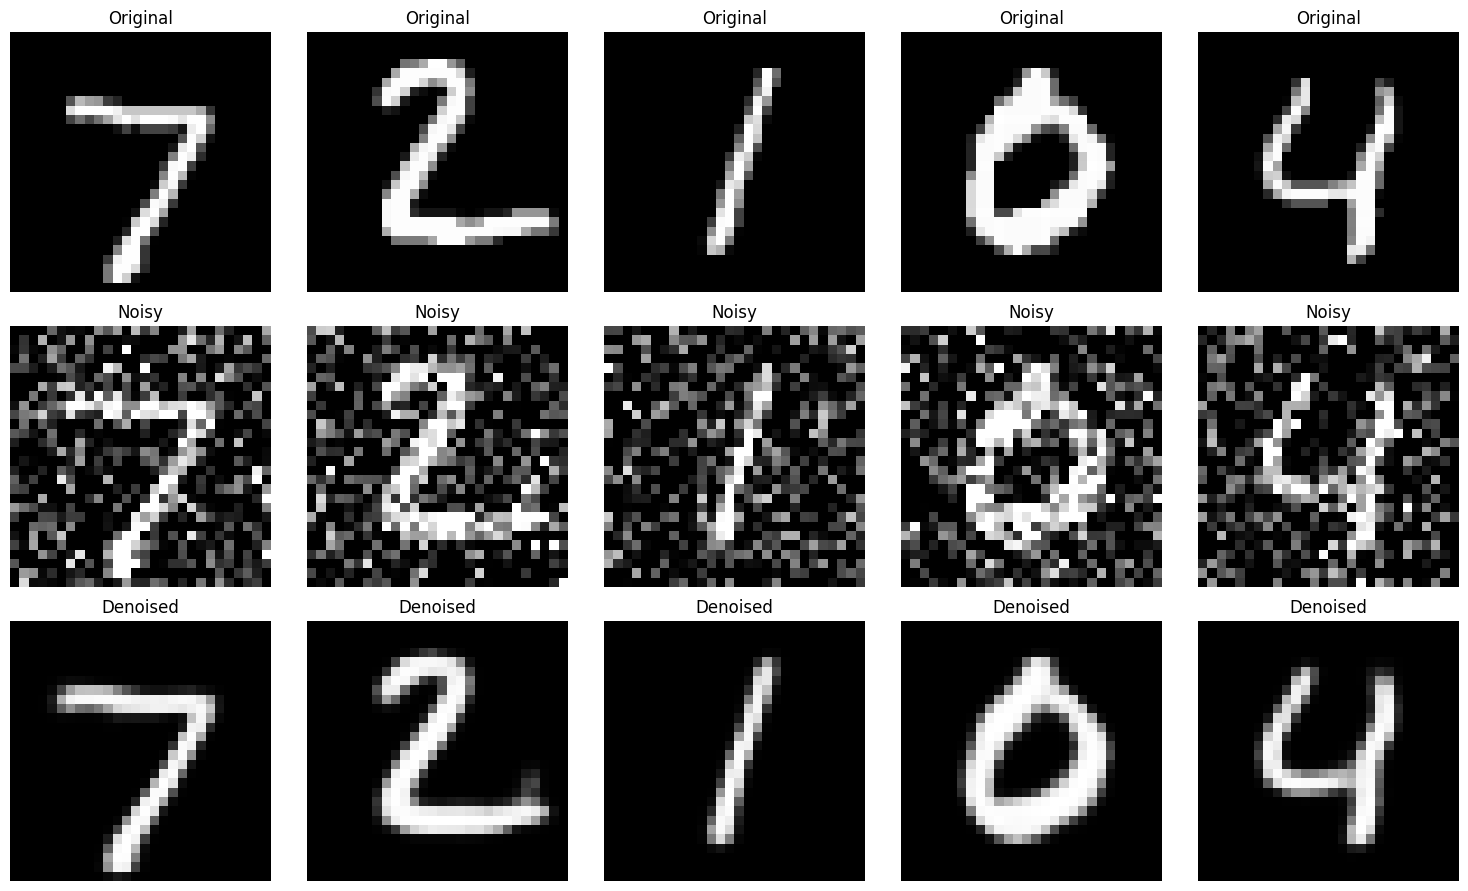

In [18]:
n = 5
plt.figure(figsize=(15,9))

for i in range(n):

    # Original Images
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy Images
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised Images
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Model Evaluation

In [24]:
reconstruction_error = np.mean(np.square(x_test - decoded_imgs))
print("Mean Reconstruction Error:", reconstruction_error)

Mean Reconstruction Error: 0.0069952644


## Innovation: Analysis of Noise Levels and Reconstruction Performance

### Part 1: Impact of Noise Intensity on Image Quality

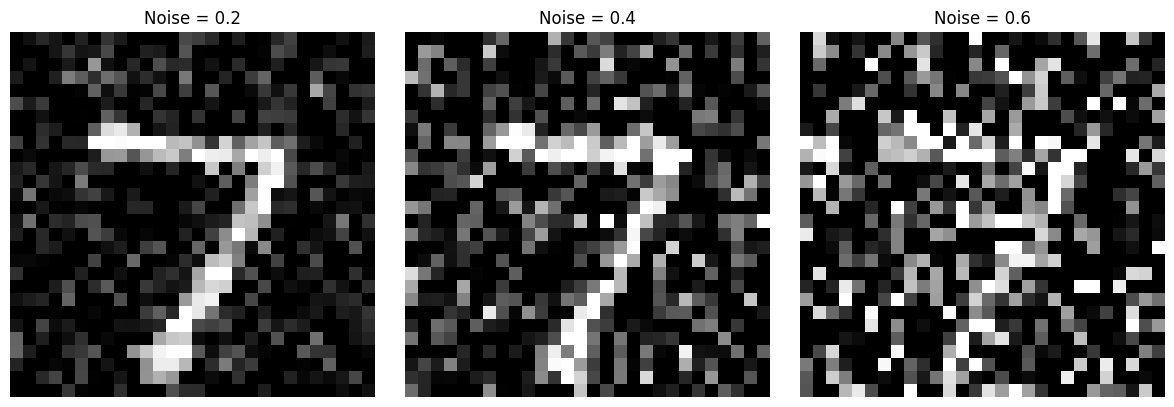

In [20]:
noise_levels = [0.2, 0.4, 0.6]

plt.figure(figsize=(12,4))

for i, noise in enumerate(noise_levels):

    noisy_image = x_test[0] + noise * np.random.normal(
        loc=0.0,
        scale=1.0,
        size=x_test[0].shape
    )

    noisy_image = np.clip(noisy_image, 0., 1.)

    plt.subplot(1,3,i+1)
    plt.imshow(noisy_image.reshape(28,28), cmap='gray')
    plt.title(f"Noise = {noise}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Part 2: Reconstruction Error at Different Noise Levels

In [21]:
noise_levels = [0.2, 0.4, 0.6]

for noise in noise_levels:

    noisy = x_test + noise * np.random.normal(
        loc=0.0,
        scale=1.0,
        size=x_test.shape
    )

    noisy = np.clip(noisy, 0., 1.)

    reconstructed = autoencoder.predict(noisy, verbose=0)

    mse = np.mean(np.square(x_test - reconstructed))

    print(f"Noise Level {noise}: MSE = {mse:.6f}")

Noise Level 0.2: MSE = 0.003900
Noise Level 0.4: MSE = 0.006998
Noise Level 0.6: MSE = 0.018213


### Innovation Observation

To further evaluate the robustness of the denoising autoencoder, different noise levels were tested.

- Increasing noise intensity resulted in more corrupted input images.
- The reconstruction error increased as the noise level increased.
- Despite higher corruption levels, the autoencoder was able to preserve the overall digit structure.
- This experiment demonstrates the effectiveness of the trained model under varying noise conditions.

## Overall Observations

- The MNIST dataset was successfully preprocessed and used for training the denoising autoencoder.
- Noise was added to create noisy input images while preserving the original images as targets.
- Training and validation loss decreased consistently, indicating effective learning.
- The autoencoder successfully reconstructed cleaner versions of noisy digit images.
- Most digit structures were preserved after denoising, although slight blurring was observed in some cases.
- The model demonstrated good performance in removing noise while maintaining important visual features.

## Challenges Faced

- Selecting an appropriate noise level that was challenging while keeping digits recognizable.
- Designing an encoder-decoder architecture capable of effective feature extraction and reconstruction.
- Balancing reconstruction quality and training time during model development.

## Conclusion

A Denoising Autoencoder was successfully developed and trained using the MNIST dataset. The model learned to reconstruct clean images from noisy inputs and demonstrated effective noise removal while preserving digit structures. Experimental analysis with different noise levels showed that reconstruction becomes more challenging as noise intensity increases. Overall, the project highlights the effectiveness of autoencoders for image denoising and image restoration tasks.